**Ensemble Models**

**Import required libraries**

In [1]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
# Reading data 
import pandas as pd

data = pd.read_csv("C:/MAFAS/APU/CT046-3-M-AML/CT046 - LABS/Python LAB MATERIALS/Lab 11 - Ensemble Models/Churn_Modelling.csv")
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
data.shape

(10000, 14)

In [4]:
data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis = 1)
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
# Variable Assignment
x = data.drop('Exited', axis = 1)
y = data['Exited']

y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [6]:
# Data Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

print("Length of train set: ", x_train.shape)
print("Length of test set: ", x_test.shape)

Length of train set:  (8000, 10)
Length of test set:  (2000, 10)


Exited
0    6356
1    1644
Name: count, dtype: int64


<Axes: xlabel='Exited', ylabel='count'>

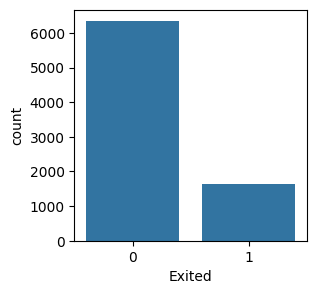

In [7]:
# Class Imbalance Visualization on y_train
print(y_train.value_counts())
plt.figure(figsize = (3,3))
sns.countplot(x = y_train)

**Variable Encoding**

In [8]:
le_geography = LabelEncoder()
x_train['Geography'] = le_geography.fit_transform(x_train['Geography'])
x_test['Geography'] = le_geography.transform(x_test['Geography'])

le_gender = LabelEncoder()
x_train['Gender'] = le_gender.fit_transform(x_train['Gender'])
x_test['Gender'] = le_gender.transform(x_test['Gender'])

**Class Balancing**

In [9]:
x_train, y_train = SMOTE().fit_resample(x_train, y_train)

y_train.value_counts()

Exited
0    6356
1    6356
Name: count, dtype: int64

**Data Standardization**

In [10]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

**AdaBoost Classifier**

In [11]:
from sklearn.ensemble import AdaBoostClassifier

ada_boost = AdaBoostClassifier() #  If None, then the base estimator is DecisionTreeClassifier initialized with max_depth = 1

parameters = {
    'n_estimators': list(range(50, 100)),
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1],
    'random_state' : list(range(1, 10)),
    }

gs_ada = GridSearchCV(estimator = ada_boost, param_grid = parameters, scoring = 'accuracy', cv = 3)
gs_ada.fit(x_train, y_train)
best_parameters = gs_ada.best_params_  
best_score = gs_ada.best_score_ 
print(best_parameters)
print(best_score)

best_model = gs_ada.best_estimator_

# Predict
y_pred = best_model.predict(x_test)

# Get the accuracy score
ada_acc=accuracy_score(y_test, y_pred)
ada_pre=precision_score(y_test, y_pred, average = 'weighted')
ada_recall=recall_score(y_test, y_pred, average = 'weighted')
ada_f1=f1_score(y_test, y_pred, average = 'weighted')

print("Adaboost - Accuracy: {:.3f}.".format(ada_acc))
print("Adaboost - Precision: {:.3f}.".format(ada_pre))
print("Adaboost - Recall: {:.3f}.".format(ada_recall))
print("Adaboost - F1_Score: {:.3f}.".format(ada_f1))

{'learning_rate': 0.1, 'n_estimators': 99, 'random_state': 1}
0.7837525876094954
Adaboost - Accuracy: 0.788.
Adaboost - Precision: 0.822.
Adaboost - Recall: 0.788.
Adaboost - F1_Score: 0.801.


**XGB Classifier**

In [12]:
# %pip install xgboost
from xgboost import XGBClassifier
XGB = XGBClassifier()

parameters = {
    'max_depth': list(range(3, 10)),
    'min_child_weight': list(range(1, 5)),
    'gamma': [i/10.0 for i in range(0, 5)],
    'subsample': [i/10.0 for i in range(6, 10)],
    'colsample_bytree': [i/10.0 for i in range(6, 10)],
    'reg_alpha': [0, 0.001, 0.005, 0.01, 0.05],
}

XGB_SE = GridSearchCV(estimator = XGB, param_grid = parameters, scoring = 'accuracy', cv = 3)
XGB_SE.fit(x_train,y_train)
best_parameters = XGB_SE.best_params_  
best_score = XGB_SE.best_score_ 
print(best_parameters)
print(best_score)

best_model = XGB_SE.best_estimator_

# Predict
y_pred = best_model.predict(x_test)

# Get the accuracy score
XGB_acc = accuracy_score(y_test, y_pred)
XGB_pre = precision_score(y_test, y_pred, average = 'weighted')
XGB_recall = recall_score(y_test, y_pred, average = 'weighted')
XGB_f1 = f1_score(y_test, y_pred, average = 'weighted')

print("XGB - Accuracy: {:.3f}.".format(XGB_acc))
print("XGB - Precision: {:.3f}.".format(XGB_pre))
print("XGB - Recall: {:.3f}.".format(XGB_recall))
print("XGB - F1_Score: {:.3f}.".format(XGB_f1))

{'colsample_bytree': 0.9, 'gamma': 0.1, 'max_depth': 9, 'min_child_weight': 1, 'reg_alpha': 0, 'subsample': 0.9}
0.8575417040581507
XGB - Accuracy: 0.818.
XGB - Precision: 0.829.
XGB - Recall: 0.818.
XGB - F1_Score: 0.823.


**Bagging Classifier**

In [13]:
from sklearn.ensemble import BaggingClassifier

bagging = BaggingClassifier() # Base estimator is a DecisionTreeClassifier. Can use any suitable ML model.

parameters = {
    'n_estimators': list(range(10, 50)),
    'max_samples' : list(range(1, 5)),
    'max_features' : list(range(1, 5))
}

bagging_SE = GridSearchCV(estimator = bagging, param_grid = parameters, scoring = 'accuracy', cv = 3)
bagging_SE.fit(x_train,y_train)
best_parameters = bagging_SE.best_params_  
best_score = bagging_SE.best_score_ 
print(best_parameters)
print(best_score)

bagging_SE.fit(x_train,y_train)

best_model = bagging_SE.best_estimator_

# Predict
y_pred = best_model.predict(x_test)

# Get the accuracy score
bagging_acc = accuracy_score(y_test, y_pred)
bagging_pre = precision_score(y_test, y_pred, average = 'weighted')
bagging_recall = recall_score(y_test, y_pred, average = 'weighted')
bagging_f1 = f1_score(y_test, y_pred, average = 'weighted')

print("Bagging - Accuracy: {:.3f}.".format(bagging_acc))
print("Bagging - Precision: {:.3f}.".format(bagging_pre))
print("Bagging - Recall: {:.3f}.".format(bagging_recall))
print("Bagging - F1_Score: {:.3f}.".format(bagging_f1))

{'max_features': 4, 'max_samples': 4, 'n_estimators': 43}
0.7499262937137866
Bagging - Accuracy: 0.576.
Bagging - Precision: 0.785.
Bagging - Recall: 0.576.
Bagging - F1_Score: 0.617.


**Extra Trees Classifier**

In [11]:
from sklearn.ensemble import ExtraTreesClassifier

ext = ExtraTreesClassifier()

parameters = {
    'n_estimators': list(range(100, 300, 50)),
    'criterion' : ['gini', 'entropy', 'log_loss'],
    'max_features' : ['sqrt', 'log2'],
}

ext_SE = GridSearchCV(estimator = ext, param_grid = parameters, scoring = 'accuracy', cv = 3)
ext_SE.fit(x_train,y_train)
best_parameters = ext_SE.best_params_  
best_score = ext_SE.best_score_ 
print(best_parameters)
print(best_score)

best_model = ext_SE.best_estimator_

# Predict
y_pred = best_model.predict(x_test)

# Get the accuracy score
ext_acc = accuracy_score(y_test, y_pred)
ext_pre = precision_score(y_test, y_pred, average = 'weighted')
ext_recall = recall_score(y_test, y_pred, average = 'weighted')
ext_f1 = f1_score(y_test, y_pred, average = 'weighted')

print("Extra Trees - Accuracy: {:.3f}.".format(ext_acc))
print("Extra Trees - Precision: {:.3f}.".format(ext_pre))
print("Extra Trees - Recall: {:.3f}.".format(ext_recall))
print("Extra Trees - F1_Score: {:.3f}.".format(ext_f1))

{'criterion': 'gini', 'max_features': 'sqrt', 'n_estimators': 100}
0.8460567034776707
Extra Trees - Accuracy: 0.817.
Extra Trees - Precision: 0.832.
Extra Trees - Recall: 0.817.
Extra Trees - F1_Score: 0.823.


**Stacking Classifier**

In [12]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import AdaBoostClassifier
AB = AdaBoostClassifier(learning_rate = 0.1, n_estimators = 99, random_state = 1)

from xgboost import XGBClassifier
XGB = XGBClassifier(colsample_bytree = 0.9, gamma = 0.1, max_depth = 9, min_child_weight = 1, reg_alpha = 0, subsample = 0.9)

from sklearn.ensemble import BaggingClassifier
BG = BaggingClassifier(max_features = 4, max_samples = 4, n_estimators = 43)

from sklearn.ensemble import ExtraTreesClassifier
EXT = ExtraTreesClassifier(criterion = 'gini', max_features = 'sqrt', n_estimators = 100)

estimators = [
    ('Ada Boost', AB),
    ('Xtreme Boost', XGB),
    ('Bagging', BG),
    ('Extra Trees', EXT)
]

stc = StackingClassifier(estimators = estimators, final_estimator = LogisticRegression(), cv = 3)
stc.fit(x_train, y_train)

# Predict
y_pred = stc.predict(x_test)

# Get the accuracy score
stc_acc = accuracy_score(y_test, y_pred)
stc_pre = precision_score(y_test, y_pred, average = 'weighted')
stc_recall = recall_score(y_test, y_pred, average = 'weighted')
stc_f1 = f1_score(y_test, y_pred, average = 'weighted')

print("Stacking - Accuracy: {:.3f}.".format(stc_acc))
print("Stacking - Precision: {:.3f}.".format(stc_pre))
print("Stacking - Recall: {:.3f}.".format(stc_recall))
print("Stacking - F1_Score: {:.3f}.".format(stc_f1))

Stacking - Accuracy: 0.825.
Stacking - Precision: 0.837.
Stacking - Recall: 0.825.
Stacking - F1_Score: 0.830.
